# Creating a Drug-Like CSD Subset

In this notebook, Lipinski's Rule of 5 will be applied to entries under the 'Drug' subset of the CSD (comprising all small molecule crystal structures containing FDA approved molecules) and the entire CSD. 

First, we will load all relevant packages and libraries.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet, from_indicators
from venn import venn

from rdkit import Chem
from rdkit.Chem import Descriptors

import warnings

from ccdc import io

### Data Selection
The workflow is configured to use the CSD Drug subset for development and testing. To analyse the complete Cambridge Structural Database, change subset_name from "drug" to "CSD". No further changes to the workflow are required.

The drug subset includes FDA approved-molecules which do not necessarily comply with Lipinski's Ro5. 

First, we extract entries from the 'Drug' subset of the CSD.

In [13]:
# Select the dataset to analyse by uncommenting/commenting the relevant code below

subset_name = "CSD"
#subset_name = "drug"

if subset_name == "drug":
    reader = io.EntryReader(subset=io.Subsets.DRUG)
elif subset_name == "CSD":
    reader = io.EntryReader()

reader_output = Path(f"all_{subset_name}_properties.csv")
failed_output = Path(f"failed_{subset_name}_properties.csv")
whole_entry_output = Path(f"{subset_name}_whole_multicomponent_properties.csv")

Then, we use the function 'csd_iterator' to extract the molecule object for each entry within the 'Drug' subset and the SMILES string components. 

Each molecular component within a CSD entry is extracted and analysed independently. Components containing fewer than 10 heavy atoms are excluded prior to descriptor calculation. This removes small species such as counterions and solvent molecules that are unlikely to represent the primary drug-like component. Duplicate SMILES entries are disregarded.

In [14]:
# Iterate through entries and extract each molecular component.
# Each component is assigned the parent CCDC REFCODE together with a unique
# component identifier (e.g. ABCD01_1) to enable component-level analysis.

def csd_iterator(reader):
    """" 

    csd_iterator first extracts the molecule object for each entry then 
    the SMILES string in the database specified in the above cell.  
    It returns the identifier and the SMILES string for each molecule object
    with more than 10 heavy atoms in its SMILES string.   

    """ 
    for entry in reader:
        try:
            # Extract the CSD molecule object and its associated REFCODE.
            mol = entry.molecule
            refcode = mol.identifier.strip()
            components = mol.components
        except RuntimeError:
            # Skip entries that cannot be read from the CSD.
            continue

        # Skip entries that contain no molecular components.
        if not components:
            continue

        seen = set()

        # Yield each molecular component together with the parent REFCODE,
        # a unique component identifier and its corresponding SMILES string.
        for i, component in enumerate(components, start=1):
            smiles = component.smiles
            if not smiles:
                continue

            if smiles in seen:
                continue

            seen.add(smiles)

            heavy_atom_count = sum(1 for atom in component.atoms if atom.atomic_number > 1)
            if heavy_atom_count < 10:
                continue

            yield refcode, f"{refcode}_{i}", smiles

### Calculation of Molecular Properties

We use the output from 'csd_iterator' to calculate the molecular properties (molecular weight, number of H-bond donors, number of H-bond acceptors, and Crippen logP) using RDKit for each entry.

It outputs a pandas dataframe displaying these properties coupled with the CCDC identifier (REFCODE) and the SMILES string. It exports this dataframe to a CSV file.<br>
Molecules for which RDKit has failed to calculate properties
are output into a separate CSV file. 

In [15]:
output = Path(f"all_{subset_name}_properties.csv")
failed_output = Path(f"all_{subset_name}_properties_failed.csv")

reader_log = Path(f"all_{subset_name}_properties_log.csv")
reader_failed_log = Path(f"all_{subset_name}_properties_failed_log.csv")

#you don't need to create anything in advance in this case
#with reader_output.open("w") as f:
#    f.write("refcode,component_refcode,smiles,HBD,HBA,logP,MW")

# Initialise lists to store successfully processed components and any
# components that fail during processing.
records = []
failed_records = []

records_dataframe = pd.DataFrame(columns=["refcode", "component_refcode", "smiles", "HBD", "HBA", "logP", "MW"])
records_failed_dataframe = pd.DataFrame(columns=["refcode", "component_refcode", "stage", "error"])

# Iterate through each molecular component extracted from the CSD Drug subset.
for i, (refcode, component_refcode, smiles) in enumerate(csd_iterator(reader)):
 
    # Convert the SMILES string into an RDKit molecule object.
    mol = Chem.MolFromSmiles(smiles)

    # Record components that RDKit cannot successfully parse.
    if mol is None:
        failed_records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "stage": "smiles_parse",
            "error": "RDKit could not parse SMILES"
        })
    else:
        # Calculate the molecular descriptors required for Lipinski's Rule of Five.
        records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "smiles": smiles,
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol),
            "logP": Descriptors.MolLogP(mol),
            "MW": Descriptors.ExactMolWt(mol),
        })
    
    if (i != 0) and i % 1000 == 0:
        if len(records) > 0:
            records_dataframe_progress = pd.DataFrame(records)
            records_dataframe_progress.to_csv(reader_log, mode="a", index=False)
            records_dataframe = pd.concat([records_dataframe, records_dataframe_progress], ignore_index=True)
            records = []

        # Same as above for failed records
        if len(failed_records) > 0:
            records_failed_dataframe_progress = pd.DataFrame(failed_records)
            records_failed_dataframe_progress.to_csv(reader_failed_log, mode="a", index=False)
            records_failed_dataframe = pd.concat([records_failed_dataframe, records_failed_dataframe_progress], ignore_index=True)
            failed_records = []

# Writing the last bit of data to the output files after the loop ends
if len(records) > 0:
    records_dataframe_progress = pd.DataFrame(records)
    records_dataframe_progress.to_csv(reader_log, mode="a", index=False)
    # writing the complete dataset to the output file
    records_dataframe = pd.concat([records_dataframe, records_dataframe_progress], ignore_index=True)
    records_dataframe.to_csv(output, index=False)

if len(failed_records) > 0:
    records_failed_dataframe_progress = pd.DataFrame(failed_records)
    records_failed_dataframe_progress.to_csv(reader_failed_log, mode="a", index=False)
    # writing the complete dataset to the output file
    records_failed_dataframe = pd.concat([records_failed_dataframe, records_failed_dataframe_progress], ignore_index=True)
    records_failed_dataframe.to_csv(failed_output, index=False)



C:\Users\dkondinskaia\AppData\Local\Temp\ipykernel_37792\3259451886.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  records_dataframe = pd.concat([records_dataframe, records_dataframe_progress], ignore_index=True)


In [16]:
# Report the number of components successfully analysed.
print(f"Successfully analysed components: {len(records_dataframe)}")
print(f"Components failed to be parsed: {len(records_failed_dataframe)}")

Successfully analysed components: 967430
Components failed to be parsed: 365331


df = pandas dataframe listing entries alongside their molecular properties

In [17]:
records_dataframe.head()

,refcode,component_refcode,smiles,HBD,HBA,logP,MW
0,AABHTZ,AABHTZ_1,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,5,2.0619,354.039879
1,AACANI10,AACANI10_1,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3,0,6,-1.4280,304.056915
2,AACANI11,AACANI11_1,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3,0,6,-1.4280,304.056915
3,AACFAZ,AACFAZ_1,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492
4,AACFAZ10,AACFAZ10_1,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492


failed_df = pandas dataframe listing entries for which RDKit could not calculate the molecular properties.

In [18]:
records_failed_dataframe.head()

,refcode,component_refcode,stage,error
0,AAPUNI,AAPUNI_1,smiles_parse,RDKit could not parse SMILES
1,ABABOY,ABABOY_1,smiles_parse,RDKit could not parse SMILES
2,ABABUE,ABABUE_1,smiles_parse,RDKit could not parse SMILES
3,ABACAL,ABACAL_1,smiles_parse,RDKit could not parse SMILES
4,ABACAL01,ABACAL01_1,smiles_parse,RDKit could not parse SMILES


### Rule of Five Analysis:

The calculated molecular descriptors are compared against the Lipinski Rule of Five thresholds. Each molecule is assigned a binary pass/fail value for each rule. These values are summed to determine how many of the four criteria each molecule satisfies, and summary statistics are generated to describe the distribution across the dataset.

Components satisfying at least three of the four criteria are classified as drug-like.

Finally, parent CCDC refcodes corresponding to drug-like components are identified and listed in a .gcd file for use within CCDC software.

In [19]:
# Apply Lipinski Rule of Five thresholds
thresholds = {
    'HBD': 5,
    'HBA': 10,
    'logP': 5,
    'MW': 500
}

# Create binary pass/fail columns for each descriptor
for col, thresh in thresholds.items():
    records_dataframe[f'{col}_bin'] = (records_dataframe[col] <= thresh).astype(int)

# Calculate the number of Rule of Five criteria satisfied
bin_cols = ['HBD_bin', 'HBA_bin', 'logP_bin', 'MW_bin']
records_dataframe['bin_sum'] = records_dataframe[bin_cols].sum(axis=1)

# Components satisfying at least three of the four criteria
records_dataframe["drug_like"] = records_dataframe["bin_sum"] >= 3

# REFCODEs where at least one component satisfies all four criteria
refcodes_all_4 = (
    records_dataframe.loc[records_dataframe["bin_sum"] == 4, "refcode"]
      .drop_duplicates()
      .sort_values()
)

# REFCODEs where at least one component satisfies three or more criteria
refcodes_at_least_3 = (
    records_dataframe.loc[records_dataframe["bin_sum"] >= 3, "refcode"]
      .drop_duplicates()
      .sort_values()
)

# Export the stricter Rule of Five subset
with Path(f"{subset_name}_drug_like_refcodes_all_4.gcd").open("w") as f:
    for refcode in refcodes_all_4:
        f.write(f"{refcode}\n")

# Export the more permissive Rule of Five subset
with Path(f"{subset_name}_drug_like_refcodes_at_least_3.gcd").open("w") as f:
    for refcode in refcodes_at_least_3:
        f.write(f"{refcode}\n")

print(f"REFCODEs satisfying all four criteria: {len(refcodes_all_4)}")
print(f"REFCODEs satisfying at least three criteria: {len(refcodes_at_least_3)}")

REFCODEs satisfying all four criteria: 455326
REFCODEs satisfying at least three criteria: 627186


### Output: 

This notebook generates:

- all_{subset_name}_properties.csv:  molecular descriptors (MW, HBD, HBA and logP) for successfully analysed molecular components.
- all_{subset}_properties_failed.csv: components that could not be processed by RDKit, together with the stage at which processing failed.
- {subset_name}_drug_like_refcodes_all_4.gcd: unique CSD REFCODEs containing at least one molecular component satisfying all four Lipinski Rule of Five criteria.
- {subset_name}_drug_like_refcodes_at_least_3.gcd: unique CSD REFCODEs containing at least one molecular component satisfying at least three of the four Lipinski Rule of Five criteria (allowing one violation).

# Comparative Analysis
### Multi-Component Entries

We can investigate multi-component entries by separating the components into different entries and determining the molecular properties for each entry. The resulting dataframe is then exported to a CSV file. 

In [20]:
# Iterate through entries and extract each molecular component.
# Each component is assigned the parent CCDC REFCODE together with a unique
# component identifier (e.g. ABCD01_1) to enable component-level analysis.

def all_csd_iterator(reader):
    """" 

    csd_iterator first extracts the molecule object for each entry then 
    the SMILES string in the database specified in the above cell.  
    It returns the identifier and the SMILES string for each molecule object.  

    """ 
    for entry in reader:
        try:
            # Extract the CCDC molecule object and its associated REFCODE.
            mol = entry.molecule
            if mol is None:
                continue

            refcode = mol.identifier.strip()
            components = mol.components
        except RuntimeError:
            # Skip entries that cannot be read from the CSD.
            continue

        # Skip entries that contain no molecular components.
        if not components:
            continue

        seen = set()

        # Yield each molecular component together with the parent REFCODE,
        # a unique component identifier and its corresponding SMILES string.
        for i, component in enumerate(components, start=1):
            smiles = component.smiles
            if not smiles:
                continue

            if smiles in seen:
                continue

            seen.add(smiles)

            yield refcode, f"{refcode}_{i}", smiles

In [21]:
all_entry_output = Path(f"all_{subset_name}_all_multicomponent_properties.csv")
all_entry_failed_output = Path(f"all_{subset_name}_all_multicomponent_properties_failed.csv")

all_entry_reader_log = Path(f"all_{subset_name}_all_multicomponent_properties_log.csv")
all_entry_reader_failed_log = Path(f"all_{subset_name}_all_multicomponent_properties_failed_log.csv")

# Initialise lists to store successfully processed components and any
# components that fail during processing.
all_entry_records = []
all_entry_failed_records = []

all_entry_records_dataframe = pd.DataFrame(columns=["refcode", "component_refcode", "smiles", "HBD", "HBA", "logP", "MW"])
all_entry_records_failed_dataframe = pd.DataFrame(columns=["refcode", "component_refcode", "stage", "error"])

# Iterate through each molecular component extracted from the CSD Drug subset.
for i, (refcode, component_refcode, smiles) in enumerate(all_csd_iterator(reader)):
 
    # Convert the SMILES string into an RDKit molecule object.
    mol = Chem.MolFromSmiles(smiles)

    # Record components that RDKit cannot successfully parse.
    if mol is None:
        all_entry_failed_records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "stage": "smiles_parse",
            "error": "RDKit could not parse SMILES"
        })
    else:
        # Calculate the molecular descriptors required for Lipinski's Rule of Five.
        all_entry_records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "smiles": smiles,
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol),
            "logP": Descriptors.MolLogP(mol),
            "MW": Descriptors.ExactMolWt(mol),
        })
    
    if (i != 0) and i % 1000 == 0:
        if len(all_entry_records) > 0:
            all_entry_records_dataframe_progress = pd.DataFrame(all_entry_records)
            all_entry_records_dataframe_progress.to_csv(all_entry_reader_log, mode="a", index=False)
            all_entry_records_dataframe = pd.concat([all_entry_records_dataframe, all_entry_records_dataframe_progress], ignore_index=True)
            all_entry_records = []

        # Same as above for failed records
        if len(all_entry_failed_records) > 0:
            all_entry_records_failed_dataframe_progress = pd.DataFrame(all_entry_failed_records)
            all_entry_records_failed_dataframe_progress.to_csv(all_entry_reader_failed_log, mode="a", index=False)
            all_entry_records_failed_dataframe = pd.concat([all_entry_records_failed_dataframe, all_entry_records_failed_dataframe_progress], ignore_index=True)
            all_entry_failed_records = []

# Writing the last bit of data to the output files after the loop ends
if len(all_entry_records) > 0:
    all_entry_records_dataframe_progress = pd.DataFrame(all_entry_records)
    all_entry_records_dataframe_progress.to_csv(all_entry_reader_log, mode="a", index=False)
    # writing the complete dataset to the output file
    all_entry_records_dataframe = pd.concat([all_entry_records_dataframe, all_entry_records_dataframe_progress], ignore_index=True)
    all_entry_records_dataframe.to_csv(all_entry_output, index=False, header=False)

if len(all_entry_failed_records) > 0:
    all_entry_records_failed_dataframe_progress = pd.DataFrame(all_entry_failed_records)
    all_entry_records_failed_dataframe_progress.to_csv(all_entry_reader_failed_log, mode="a", index=False)
    # writing the complete dataset to the output file
    all_entry_records_failed_dataframe = pd.concat([all_entry_records_failed_dataframe, all_entry_records_failed_dataframe_progress], ignore_index=True)
    all_entry_records_failed_dataframe.to_csv(all_entry_failed_output, index=False, header=False)


C:\Users\dkondinskaia\AppData\Local\Temp\ipykernel_37792\700720229.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_entry_records_dataframe = pd.concat([all_entry_records_dataframe, all_entry_records_dataframe_progress], ignore_index=True)


In [22]:
# Iterate through entries.

def whole_csd_iterator(reader):
    """" 

    csd_iterator first extracts the molecule object for each entry then 
    the SMILES string in the database specified in the above cell.  
    It returns the identifier and the SMILES string for each molecule object.  

    """ 
    for entry in reader:
        try:
            # Extract the CCDC molecule object and its associated REFCODE.
            mol = entry.molecule
            if mol is None:
                continue

            refcode = mol.identifier.strip()
            smiles = mol.smiles
        except RuntimeError:
            # Skip entries that cannot be read from the CSD.
            continue

        # Skip entries that contain no molecular components.
        if not smiles:
            continue

        yield refcode, smiles

In [23]:
whole_entry_output = Path(f"all_{subset_name}_whole_entry_properties.csv")
whole_entry_failed_output = Path(f"all_{subset_name}_whole_entry_properties_failed.csv")

whole_entry_reader_log = Path(f"all_{subset_name}_whole_entry_properties_log.csv")
whole_entry_reader_failed_log = Path(f"all_{subset_name}_whole_entry_properties_failed_log.csv")

# Initialise lists to store successfully processed components and any
# components that fail during processing.
whole_entry_records = []
whole_entry_failed_records = []

whole_entry_records_dataframe = pd.DataFrame(columns=["refcode", "smiles", "HBD", "HBA", "logP", "MW"])
whole_entry_records_failed_dataframe = pd.DataFrame(columns=["refcode", "stage", "error"])

# Iterate through each molecular component extracted from the CSD Drug subset.
for i, (refcode, smiles) in enumerate(whole_csd_iterator(reader)):
 
    # Convert the SMILES string into an RDKit molecule object.
    mol = Chem.MolFromSmiles(smiles)

    # Record components that RDKit cannot successfully parse.
    if mol is None:
        whole_entry_failed_records.append({
            "refcode": refcode,
            "stage": "smiles_parse",
            "error": "RDKit could not parse SMILES"
        })
    else:
        # Calculate the molecular descriptors required for Lipinski's Rule of Five.
        whole_entry_records.append({
            "refcode": refcode,
            "smiles": smiles,
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol),
            "logP": Descriptors.MolLogP(mol),
            "MW": Descriptors.ExactMolWt(mol),
        })
    
    if (i != 0) and i % 1000 == 0:
        if len(whole_entry_records) > 0:
            whole_entry_records_dataframe_progress = pd.DataFrame(whole_entry_records)
            whole_entry_records_dataframe_progress.to_csv(whole_entry_reader_log, mode="a", index=False)
            whole_entry_records_dataframe = pd.concat([whole_entry_records_dataframe, whole_entry_records_dataframe_progress], ignore_index=True)
            whole_entry_records = []

        # Same as above for failed records
        if len(whole_entry_failed_records) > 0:
            whole_entry_records_failed_dataframe_progress = pd.DataFrame(whole_entry_failed_records)
            whole_entry_records_failed_dataframe_progress.to_csv(whole_entry_reader_failed_log, mode="a", index=False)
            whole_entry_records_failed_dataframe = pd.concat([whole_entry_records_failed_dataframe, whole_entry_records_failed_dataframe_progress], ignore_index=True)
            whole_entry_failed_records = []

# Writing the last bit of data to the output files after the loop ends
if len(whole_entry_records) > 0:
    whole_entry_records_dataframe_progress = pd.DataFrame(whole_entry_records)
    whole_entry_records_dataframe_progress.to_csv(whole_entry_reader_log, mode="a", index=False)
    # writing the complete dataset to the output file
    whole_entry_records_dataframe = pd.concat([whole_entry_records_dataframe, whole_entry_records_dataframe_progress], ignore_index=True)
    whole_entry_records_dataframe.to_csv(whole_entry_output, index=False, header=False)

if len(whole_entry_failed_records) > 0:
    whole_entry_records_failed_dataframe_progress = pd.DataFrame(whole_entry_failed_records)
    whole_entry_records_failed_dataframe_progress.to_csv(whole_entry_reader_failed_log, mode="a", index=False)
    # writing the complete dataset to the output file
    whole_entry_records_failed_dataframe = pd.concat([whole_entry_records_failed_dataframe, whole_entry_records_failed_dataframe_progress], ignore_index=True)
    whole_entry_records_failed_dataframe.to_csv(whole_entry_failed_output, index=False, header=False)


C:\Users\dkondinskaia\AppData\Local\Temp\ipykernel_37792\3229476244.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  whole_entry_records_dataframe = pd.concat([whole_entry_records_dataframe, whole_entry_records_dataframe_progress], ignore_index=True)


In [24]:
whole_entry_records_dataframe.head()

,refcode,smiles,HBD,HBA,logP,MW
0,AABHTZ,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,5,2.0619,354.039879
1,AACANI10,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3.O.O,0,6,-3.0774,340.078044
2,AACANI11,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3.O.O,0,6,-3.0774,340.078044
3,AACFAZ,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492
4,AACFAZ10,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492


We then compare the means for the different physicochemical properties when considering the whole SMILES string, when splitting multi-component entries into individual components, and the individual components of the multi-component entries with > 10 heavy atoms.

In [25]:
comparison = pd.DataFrame({
    "Whole Entry": whole_entry_records_dataframe[["HBD", "HBA", "logP", "MW"]].mean(),
    "All Components": all_entry_records_dataframe[["HBD", "HBA", "logP", "MW"]].mean(),
    "Components > 10 Heavy Atoms": records_dataframe[["HBD", "HBA", "logP", "MW"]].mean()
})

print(f"Number of Whole Entries analysed: {len(whole_entry_records_dataframe)}")
print(f"Number of components analysed: {len(all_entry_records_dataframe)}")
print(f"Number of components analysed with >10 heavy atoms: {len(records_dataframe)}")

comparison

Number of Whole Entries analysed: 864427
Number of components analysed: 1691507
Number of components analysed with >10 heavy atoms: 967430


,Whole Entry,All Components,Components > 10 Heavy Atoms
HBD,1.243992,0.573884,0.852679
HBA,5.910589,2.79157,4.359828
logP,6.010798,2.806275,5.064555
MW,699.51543,333.422789,527.142406


## Data visualisation 
Below is code which can be run to visualise data outputs.

1. Create a table to show how many entries are conforming to all, 3, 2 or 1 rules

In [26]:
row_summary = (records_dataframe["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary["percent"] = 100 * row_summary["count"] / row_summary["count"].sum()

row_summary["percent"] = row_summary["percent"].round(2)

row_summary

,count,percent
bin_sum,,
4,482925,49.92
3,185624,19.19
2,264244,27.31
1,31529,3.26
0,3108,0.32


2. We Can check that the total number of entries is the same in our table in the above cell and in our dataframe. 

In [27]:
row_summary["count"].sum() == len(records_dataframe)

np.True_

3. We also generate a table to show the number of entries satisfying each Ro5 condition.

In [28]:
col_summary = records_dataframe[bin_cols].sum().to_frame(name="count")

col_summary["percent"] = 100 * col_summary["count"] / len(records_dataframe)

col_summary["percent"] = col_summary["percent"].round(2)

col_summary

,count,percent
HBD_bin,944696,97.65
HBA_bin,912383,94.31
logP_bin,578060,59.75
MW_bin,613450,63.41


In [29]:
for c in bin_cols:
    print(c, records_dataframe[c].value_counts(dropna=False))

HBD_bin HBD_bin
1    944696
0     22734
Name: count, dtype: int64
HBA_bin HBA_bin
1    912383
0     55047
Name: count, dtype: int64
logP_bin logP_bin
1    578060
0    389370
Name: count, dtype: int64
MW_bin MW_bin
1    613450
0    353980
Name: count, dtype: int64


5. Next, we can visualise our findings as a 4-set Venn diagram.

In [30]:
total_rows = len(records_dataframe)
in_any_set = records_dataframe[bin_cols].fillna(0).astype(bool).any(axis=1).sum()
four_way = records_dataframe[bin_cols].fillna(0).astype(bool).all(axis=1).sum()

print("Total rows:", total_rows)
print("Rows in any set:", in_any_set)
print("4-way intersection:", four_way)
print("4-way as % of all rows:", 100 * four_way / total_rows)
print("4-way as % of union of sets:", 100 * four_way / in_any_set)

Total rows: 967430
Rows in any set: 964322
4-way intersection: 482925
4-way as % of all rows: 49.91834034503788
4-way as % of union of sets: 50.0792266483602


<Figure size 800x800 with 0 Axes>

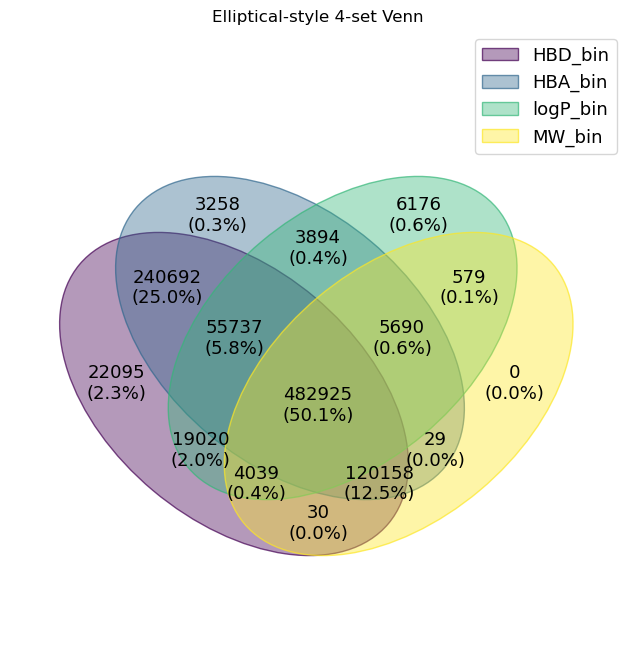

In [31]:
sets = {c: set(records_dataframe.index[records_dataframe[c] == 1]) for c in bin_cols}
plt.figure(figsize=(8, 8))

v = venn(sets, fmt="{size}\n({percentage:.1f}%)")
plt.title("Elliptical-style 4-set Venn")
plt.show()

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

6) We then generate an UpSet plot to visualise the combinations of properties that satisfy the Ro5.

In [32]:
print(records_dataframe.isna().sum())

refcode              0
component_refcode    0
smiles               0
HBD                  0
HBA                  0
logP                 0
MW                   0
HBD_bin              0
HBA_bin              0
logP_bin             0
MW_bin               0
bin_sum              0
drug_like            0
dtype: int64


In [33]:
records_dataframe.isna().sum()
records_dataframe[records_dataframe.isna().any(axis=1)]

,refcode,component_refcode,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum,drug_like


In [34]:
records_dataframe.head()

,refcode,component_refcode,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum,drug_like
0,AABHTZ,AABHTZ_1,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,5,2.0619,354.039879,1,1,1,1,4,True
1,AACANI10,AACANI10_1,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3,0,6,-1.4280,304.056915,1,1,1,1,4,True
2,AACANI11,AACANI11_1,[OH2][Ni]123OC(=O)CN41CCCN2(CCC4)CC(=O)O3,0,6,-1.4280,304.056915,1,1,1,1,4,True
3,AACFAZ,AACFAZ_1,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492,1,1,0,0,2,False
4,AACFAZ10,AACFAZ10_1,COC1=C(C(OC1=O)c1ccccc1Cl)C(C)=NN=C(C)C1=C(OC)...,0,8,5.5272,528.085492,1,1,0,0,2,False


<Figure size 1000x600 with 0 Axes>

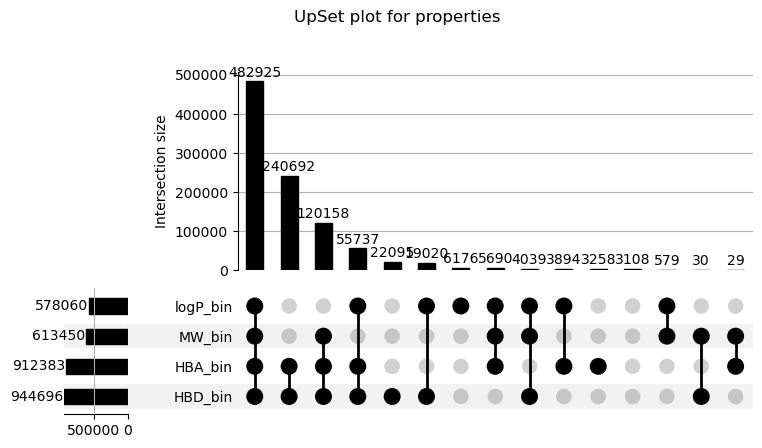

In [35]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

records_dataframe[bin_cols] = records_dataframe[bin_cols].fillna(0).astype(int)

clean_records_dataframe = records_dataframe[bin_cols].fillna(0).astype(bool)

data = from_indicators(clean_records_dataframe)

plt.figure(figsize=(10, 6))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

up.plot()
plt.suptitle("UpSet plot for properties", y=1.02)
plt.show()

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)